# Alternativas al MLP: parentesco, vecinos, árboles y modelo por padres

**La duda de fondo:** "las líneas de 2008 son todas distintas a las de años anteriores, entonces ¿qué se predice?". En selección genómica los individuos nuevos son la norma. El modelo no memoriza individuos: aprende qué alelos se asocian con rendimiento y los aplica a individuos nuevos, y funciona en la medida en que los nuevos sean **parientes** de los de entrenamiento. Este notebook lo mide en lugar de suponerlo.

**Secciones**
1. **PCA y parentesco:** ¿las líneas de 2008 caen dentro de la nube genética de los años anteriores? ¿Qué tan cerca están sus parientes más próximos?
2. **Modelos** (mismo esquema temporal: entrenar con años < t, probar en t):
   - `ridge`: la referencia (equivale a gBLUP).
   - `knn`: predice con el rendimiento de las líneas genéticamente más cercanas.
   - `random_forest` y `xgboost`: modelos no lineales sobre componentes principales (+ los SNPs más informativos en xgboost).
   - `parents_only`: el rendimiento medio esperado de una familia según sus **padres** (efecto de cada padre estimado en familias de años anteriores). Solo aporta diferencias *entre* familias.
   - `within_only`: ridge sobre genotipos **centrados dentro de cada familia**. Solo aporta diferencias *dentro* de familia.
   - `parents+within`: la suma de las dos (padres para la familia, marcadores para la línea).
3. **Exactitud según parentesco** y **clustering genético:** ¿dónde funciona el modelo y dónde no?

**Prerrequisitos:** `build_dataset.py` ya ejecutado. Empieza con `QUICK_RUN = True`.

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors, KNeighborsRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
import xgboost as xgb


def find_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "DIGITALTOOL").is_dir():
            return d
    raise FileNotFoundError("Run the notebook from inside the Hackolombia repo")


BASE_DIR = find_root(Path.cwd().resolve())
DATA_DIR = BASE_DIR / "DIGITALTOOL" / "data" / "processed" / "prediction"
sys.path.insert(0, str(BASE_DIR / "DIGITALTOOL" / "src" / "03_prediction"))
from ridge_temporal import pearson, metrics  # same metrics as the other notebooks

In [2]:
QUICK_RUN = True   # True: test year 2008 only, small forests (smoke test)

CFG = dict(
    max_snp_na=0.20,
    test_years=[2008] if QUICK_RUN else [2006, 2007, 2008],
    n_pcs=50,
    ridge_alphas=[10, 50, 250, 1000],        # y is in sd units, so these are ~ridge_temporal lambdas / 140
    parent_alphas=[10, 100, 1000, 10000],
    knn_k=[20, 100, 300],
    rf_trees=30 if QUICK_RUN else 200,
    xgb_trees=60 if QUICK_RUN else 500,
    top_snps=300,                            # xgboost also sees the top SNPs by within-family effect
    n_clusters=8,
    weight_cap=10,
)
PLOT_YEAR = CFG["test_years"][-1]

## 1. Datos

In [3]:
X_raw = np.load(DATA_DIR / "X.npy", mmap_mode="r")
lines = pd.read_parquet(DATA_DIR / "lines.parquet")
years = lines["YEAR"].to_numpy()
pops = lines["POP"].to_numpy()
pre = years < 2008

keep = np.where(np.isnan(X_raw).mean(axis=0) < CFG["max_snp_na"])[0]
X = np.asarray(X_raw[:, keep], dtype=np.float32)
mu = np.nanmean(X[pre], axis=0)                      # imputation / scaling use pre-2008 lines only
for j in range(X.shape[1]):
    col = X[:, j]
    col[np.isnan(col)] = mu[j]
X -= mu
sd = X[pre].std(axis=0); sd[sd < 1e-6] = 1.0
X /= sd
print(f"{X.shape[0]} lines, {X.shape[1]} SNPs")

centered = lines["BLUE"] - lines.groupby("YEAR")["BLUE"].transform("mean")
y_sd = float(centered[pre].std())
y = (centered / y_sd).to_numpy(dtype=np.float32)      # year-centered BLUE in sd units
w = np.clip(lines["N_OBS"].to_numpy(dtype=np.float32), 1, CFG["weight_cap"])
w = (w / w.mean()).astype(np.float32)

# Parents per family (0 = unknown)
par_tab = pd.read_csv(DATA_DIR / "parents.csv").set_index("POP")
pid = {p: i + 1 for i, p in enumerate(pd.unique(par_tab[["PARENT1", "PARENT2"]].to_numpy().ravel()))}
N_PARENTS = len(pid)

# Genotypes and yield centered within each family (used by the within-family models)
Xw, yw = X.copy(), y.copy()
pop_codes, pop_u = pd.factorize(pops)
for c in range(len(pop_u)):
    ii = np.where(pop_codes == c)[0]
    Xw[ii] -= Xw[ii].mean(axis=0)
    yw[ii] -= yw[ii].mean()

68421 lines, 2445 SNPs


## 2. ¿Se parecen las líneas de 2008 a las de años anteriores?

PCA de los genotipos (ajustado solo con líneas < 2008) y distancia de cada línea de prueba a sus 10 parientes más cercanos del entrenamiento. Como referencia, se hace lo mismo para 2007 frente a los años < 2007.

variance explained by first PCs: [0.111 0.062 0.036 0.032 0.029] | 50 PCs: 0.595


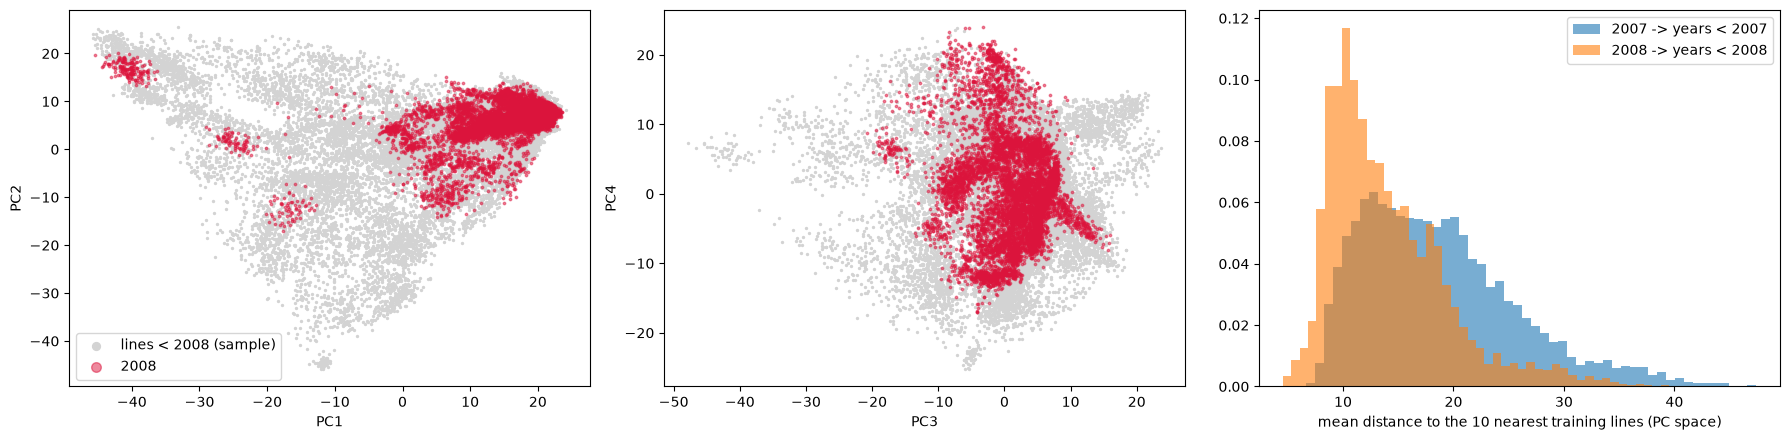

median distance to nearest relatives: 2008: 12.69 | 2007: 17.75


In [4]:
rng = np.random.default_rng(0)
sub = rng.choice(np.where(pre)[0], size=min(20000, pre.sum()), replace=False)
pca = PCA(n_components=CFG["n_pcs"], svd_solver="randomized", random_state=0).fit(X[sub])
Z = pca.transform(X).astype(np.float32)
print("variance explained by first PCs:", pca.explained_variance_ratio_[:5].round(3), "| 50 PCs:", pca.explained_variance_ratio_.sum().round(3))


def knn_dist(train_idx, query_idx, k=10):
    nn = NearestNeighbors(n_neighbors=k, n_jobs=-1).fit(Z[train_idx])
    return nn.kneighbors(Z[query_idx])[0].mean(axis=1)


tr_p, te_p = np.where(years < PLOT_YEAR)[0], np.where(years == PLOT_YEAR)[0]
d_plot = knn_dist(tr_p, te_p)
ref_year = PLOT_YEAR - 1
d_ref = knn_dist(np.where(years < ref_year)[0], np.where(years == ref_year)[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
old = rng.choice(np.where(years < PLOT_YEAR)[0], size=15000, replace=False)
new = np.where(years == PLOT_YEAR)[0]
for ax, (a, b) in zip(axes[:2], [(0, 1), (2, 3)]):
    ax.scatter(Z[old, a], Z[old, b], s=2, c="lightgray", label=f"lines < {PLOT_YEAR} (sample)")
    ax.scatter(Z[new, a], Z[new, b], s=3, c="crimson", alpha=0.5, label=str(PLOT_YEAR))
    ax.set_xlabel(f"PC{a + 1}"); ax.set_ylabel(f"PC{b + 1}")
axes[0].legend(markerscale=4)
axes[2].hist(d_ref, bins=50, alpha=0.6, density=True, label=f"{ref_year} -> years < {ref_year}")
axes[2].hist(d_plot, bins=50, alpha=0.6, density=True, label=f"{PLOT_YEAR} -> years < {PLOT_YEAR}")
axes[2].set_xlabel("mean distance to the 10 nearest training lines (PC space)"); axes[2].legend()
plt.tight_layout(); plt.show()
print(f"median distance to nearest relatives: {PLOT_YEAR}: {np.median(d_plot):.2f} | {ref_year}: {np.median(d_ref):.2f}")

## 3. Modelos con ventana creciente

Para cada año de prueba t se eligen los hiperparámetros con el año t-1 (entrenando con años < t-1) y luego se reentrena con años < t. El año t no decide nada. Métricas: `r_all` (todas las líneas), `r_within` (dentro de cada familia), `r_family` (medias por familia: capacidad *entre* familias) y ganancia del top 20%.

In [5]:
def tune_and_predict(fit_predict, grid, t):
    tr_prev, val = np.where(years < t - 1)[0], np.where(years == t - 1)[0]
    tr_all, te = np.where(years < t)[0], np.where(years == t)[0]
    if len(grid) > 1:
        scores = [pearson(fit_predict(tr_prev, val, g), y[val]) for g in grid]
        best = grid[int(np.nanargmax(scores))]
    else:
        best = grid[0]
    return fit_predict(tr_all, te, best), best


def m_ridge(tr, te, alpha):
    m = Ridge(alpha=alpha, solver="cholesky").fit(X[tr], y[tr], sample_weight=w[tr])
    return m.predict(X[te])


def m_within(tr, te, alpha):
    m = Ridge(alpha=alpha, fit_intercept=False, solver="cholesky").fit(Xw[tr], yw[tr], sample_weight=w[tr])
    return m.predict(Xw[te])


def m_knn(tr, te, k):
    return KNeighborsRegressor(n_neighbors=k, weights="distance", n_jobs=-1).fit(Z[tr], y[tr]).predict(Z[te])


def m_rf(tr, te, _):
    m = RandomForestRegressor(n_estimators=CFG["rf_trees"], min_samples_leaf=30, max_features=0.33,
                              max_samples=0.5, n_jobs=-1, random_state=0)
    return m.fit(Z[tr], y[tr], sample_weight=w[tr]).predict(Z[te])


def m_xgb(tr, te, _):
    r = (Xw[tr].T @ yw[tr]) / np.sqrt((Xw[tr] ** 2).sum(axis=0) * (yw[tr] ** 2).sum() + 1e-9)
    top = np.argsort(-np.abs(r))[:CFG["top_snps"]]
    feats = lambda idx: np.hstack([Z[idx], X[idx][:, top]])
    m = xgb.XGBRegressor(n_estimators=CFG["xgb_trees"], learning_rate=0.05, max_depth=4, subsample=0.7,
                         colsample_bytree=0.5, min_child_weight=50, tree_method="hist", n_jobs=-1, random_state=0)
    return m.fit(feats(tr), y[tr], sample_weight=w[tr]).predict(feats(te))


# --- Parent (GCA-like) model: family mean ~ effects of its two parents, learned from earlier families ---
fam = (pd.DataFrame({"POP": pops, "YEAR": years, "y": y}).groupby("POP")
       .agg(YEAR=("YEAR", "first"), n=("y", "size"), y=("y", "mean")))
fam["p1"] = par_tab["PARENT1"].reindex(fam.index).map(pid).fillna(0).astype(int)
fam["p2"] = par_tab["PARENT2"].reindex(fam.index).map(pid).fillna(0).astype(int)


def parent_design(f, seen):
    P = np.zeros((len(f), N_PARENTS + 1))
    for i, (a, b) in enumerate(zip(f["p1"].to_numpy(), f["p2"].to_numpy())):
        for p in (a, b):
            if p in seen:
                P[i, p] += 1
    return P


def family_prediction(train_years_mask, test_years_mask, alpha):
    ftr, fte = fam[train_years_mask(fam["YEAR"])], fam[test_years_mask(fam["YEAR"])]
    seen = set(ftr["p1"]) | set(ftr["p2"])
    seen.discard(0)
    m = Ridge(alpha=alpha).fit(parent_design(ftr, seen), ftr["y"].to_numpy(), sample_weight=ftr["n"].to_numpy())
    return pd.Series(m.predict(parent_design(fte, seen)), index=fte.index)


def family_r(pred_series_by_pop, t):
    fte = fam[fam["YEAR"] == t]
    return pearson(pred_series_by_pop.reindex(fte.index).to_numpy(), fte["y"].to_numpy().astype(float))


def m_parents(t):
    """Returns (family-only prediction, family+within prediction, chosen alphas) for test year t."""
    # choose the parent penalty on year t-1 (families of years < t-1 as training)
    scores = [family_r(family_prediction(lambda s: s < t - 1, lambda s: s == t - 1, a), t - 1) for a in CFG["parent_alphas"]]
    a_par = CFG["parent_alphas"][int(np.nanargmax(scores))]
    fam_pred = family_prediction(lambda s: s < t, lambda s: s == t, a_par)
    te = np.where(years == t)[0]
    fam_te = fam_pred.reindex(pops[te]).to_numpy()
    fam_te = np.where(np.isnan(fam_te), 0.0, fam_te)
    # within-family part: alpha chosen on year t-1 by within-family r
    tr_prev, val = np.where(years < t - 1)[0], np.where(years == t - 1)[0]
    sc_w = [metrics(m_within(tr_prev, val, a), y[val].astype(np.float64), pops[val])["r_within"] for a in CFG["ridge_alphas"]]
    a_w = CFG["ridge_alphas"][int(np.nanargmax(sc_w))]
    within = m_within(np.where(years < t)[0], te, a_w)
    return fam_te, fam_te + within, (a_par, a_w)


def fam_r_from_pred(pred, idx):
    d = pd.DataFrame({"p": pred, "y": y[idx], "pop": pops[idx]}).groupby("pop").mean()
    return pearson(d["p"].to_numpy(), d["y"].to_numpy().astype(float))

In [6]:
MODELS = {
    "ridge": (m_ridge, CFG["ridge_alphas"]),
    "knn": (m_knn, CFG["knn_k"]),
    "random_forest": (m_rf, [None]),
    "xgboost": (m_xgb, [None]),
}
rows, preds = [], {}
for t in CFG["test_years"]:
    te = np.where(years == t)[0]
    out = {}
    for name, (fn, grid) in MODELS.items():
        t0 = time.time()
        out[name], best = tune_and_predict(fn, grid, t)
        print(f"[{t}] {name:14s} hp={best} ({time.time() - t0:.0f}s)")
    t0 = time.time()
    out["parents_only"], out["parents+within"], hp = m_parents(t)
    out["within_only"] = out["parents+within"] - out["parents_only"]
    print(f"[{t}] parents model: alpha_parents={hp[0]}, alpha_within={hp[1]} ({time.time() - t0:.0f}s)")
    for name, pred in out.items():
        m = metrics(pred, y[te].astype(np.float64), pops[te])
        m.update(model=name, test_year=t, r_family=fam_r_from_pred(pred, te))
        rows.append(m)
        preds.setdefault(name, {})[t] = pred

res = pd.DataFrame(rows)
for c in ("gain_all", "oracle_gain_all", "gain_within", "oracle_gain_within"):
    res[c] = res[c] * y_sd
order = ["ridge", "knn", "random_forest", "xgboost", "parents_only", "within_only", "parents+within"]
show = res.set_index(["test_year", "model"]).loc[[(t, m) for t in CFG["test_years"] for m in order]]
show[["r_all", "r_within", "r_family", "gain_all", "gain_within"]].round(3)

[2008] ridge          hp=1000 (8s)
[2008] knn            hp=300 (2s)
[2008] random_forest  hp=None (2s)
[2008] xgboost        hp=None (1s)
[2008] parents model: alpha_parents=10, alpha_within=1000 (6s)


r_all  r_within  r_family  gain_all  gain_within
test_year model                                                           
2008      ridge           0.139     0.089     0.109     2.286        1.014
          knn             0.066     0.003     0.069     0.984       -0.027
          random_forest   0.137     0.020     0.168     1.713        0.189
          xgboost         0.233     0.032     0.235     6.753        0.329
          parents_only    0.168     0.000     0.196     1.572        0.119
          within_only     0.089     0.152    -0.045     1.103        1.875
          parents+within  0.190     0.152     0.196     3.570        1.875

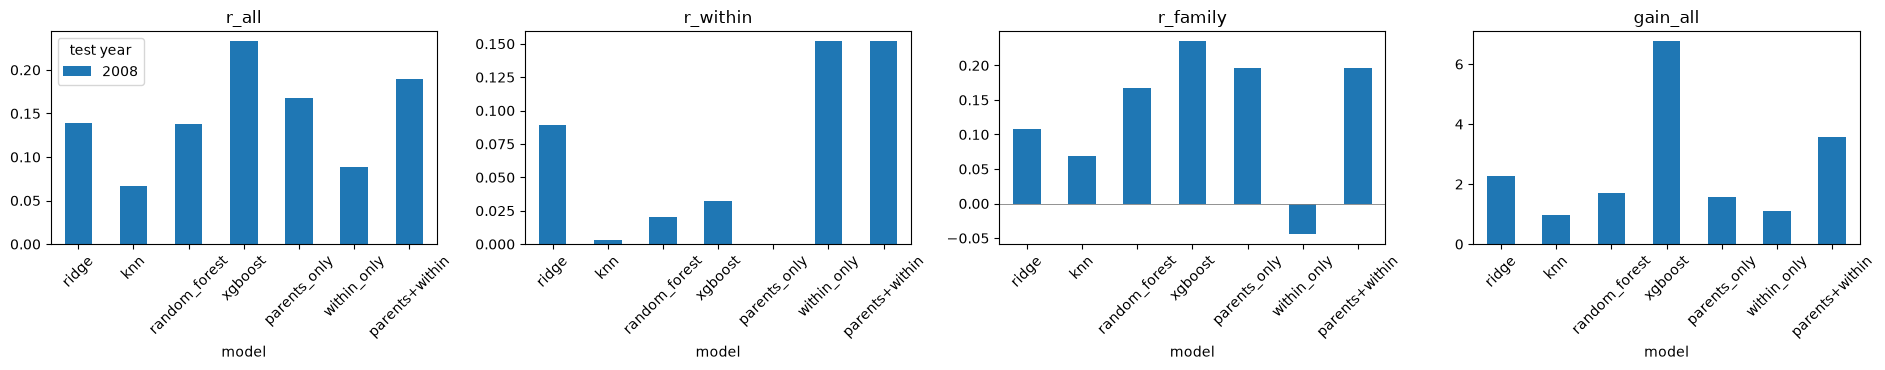

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(19, 3.8))
for ax, m in zip(axes, ["r_all", "r_within", "r_family", "gain_all"]):
    piv = res.pivot(index="model", columns="test_year", values=m).loc[order]
    piv.plot.bar(ax=ax, rot=45, legend=False)
    ax.set_title(m); ax.axhline(0, color="gray", lw=0.6)
axes[0].legend(title="test year")
plt.tight_layout(); plt.show()

**Cómo leer la tabla:** `parents_only` alto en `r_family` y `within_only` alto en `r_within` indican de dónde viene cada señal. Si `parents+within` supera al `ridge`, separar los dos niveles ayuda. Si un modelo no lineal (`random_forest`, `xgboost`) no supera al `ridge`, la relación entre marcadores y rendimiento es esencialmente aditiva y no hay que buscar más complejidad.

## 4. ¿Dónde funciona el modelo? Exactitud según parentesco y clustering genético

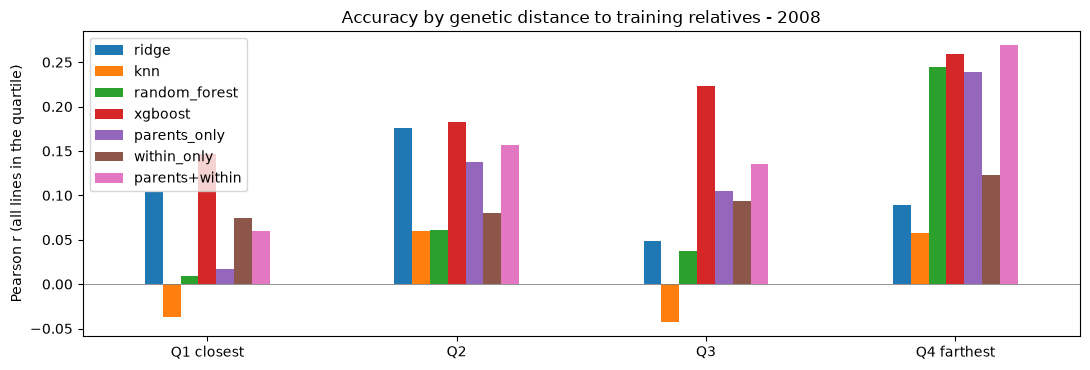

,ridge,knn,random_forest,xgboost,parents_only,within_only,parents+within
Q1 closest,0.104,-0.036,0.009,0.146,0.017,0.075,0.060
Q2,0.176,0.059,0.061,0.183,0.138,0.081,0.157
Q3,0.048,-0.043,0.037,0.223,0.105,0.093,0.135
Q4 farthest,0.089,0.058,0.244,0.259,0.239,0.123,0.269


In [8]:
# Accuracy by relatedness quartile (distance to nearest training relatives, PLOT_YEAR)
q = pd.qcut(d_plot, 4, labels=["Q1 closest", "Q2", "Q3", "Q4 farthest"])
te_idx = np.where(years == PLOT_YEAR)[0]
rel = {name: [pearson(preds[name][PLOT_YEAR][q == lv], y[te_idx][q == lv].astype(float)) for lv in q.categories]
       for name in order}
rel = pd.DataFrame(rel, index=q.categories)
ax = rel.plot.bar(figsize=(11, 3.8), rot=0)
ax.set_ylabel("Pearson r (all lines in the quartile)"); ax.axhline(0, color="gray", lw=0.6)
ax.set_title(f"Accuracy by genetic distance to training relatives - {PLOT_YEAR}")
plt.tight_layout(); plt.show()
rel.round(3)

In [9]:
# Genetic clusters (k-means on PCs, all lines): representation in training vs the test year, and accuracy per cluster
km = MiniBatchKMeans(n_clusters=CFG["n_clusters"], random_state=0, n_init=5, batch_size=4096).fit(Z)
cl = km.labels_
tr_mask = years < PLOT_YEAR
tab = pd.DataFrame({
    "n_train": [(cl[tr_mask] == c).sum() for c in range(CFG["n_clusters"])],
    "n_test": [(cl[years == PLOT_YEAR] == c).sum() for c in range(CFG["n_clusters"])],
})
cl_te = cl[years == PLOT_YEAR]
for name in ["ridge", "parents+within", "xgboost"]:
    tab[f"r_{name}"] = [pearson(preds[name][PLOT_YEAR][cl_te == c], y[te_idx][cl_te == c].astype(float))
                        if (cl_te == c).sum() >= 100 else np.nan for c in range(CFG["n_clusters"])]
tab["share_of_test"] = tab["n_test"] / tab["n_test"].sum()
tab.round(3)

,n_train,n_test,r_ridge,r_parents+within,r_xgboost,share_of_test
0,6178,333,-0.024,0.025,0.201,0.045
1,7986,4,NaN,NaN,NaN,0.001
2,4469,12,NaN,NaN,NaN,0.002
3,11963,3196,0.033,0.156,0.112,0.430
4,2220,66,NaN,NaN,NaN,0.009
5,7406,15,NaN,NaN,NaN,0.002
6,4695,181,0.030,0.341,0.187,0.024
7,16075,3622,0.175,0.193,0.231,0.488


In [10]:
# Export predictions for the last test year
te = np.where(years == PLOT_YEAR)[0]
out = pd.DataFrame({"LINE_ID": lines["LINE_ID"].to_numpy()[te], "POP": pops[te], "BLUE": lines["BLUE"].to_numpy()[te]})
for name in order:
    out[f"pred_{name}"] = preds[name][PLOT_YEAR]
out["dist_to_relatives"] = d_plot
out.to_csv(DATA_DIR / f"alternatives_predictions_{PLOT_YEAR}.csv", index=False)
res.to_csv(DATA_DIR / "alternatives_results.csv", index=False)
k = int(round(len(out) * 0.20))
print(f"Year {PLOT_YEAR}: all lines {out['BLUE'].mean():.2f} | true top 20% {out.nlargest(k, 'BLUE')['BLUE'].mean():.2f}")
for name in order:
    print(f"  {name:15s} top 20% predicted: {out.nlargest(k, f'pred_{name}')['BLUE'].mean():.2f}")

Year 2008: all lines 206.16 | true top 20% 224.92
  ridge           top 20% predicted: 208.45
  knn             top 20% predicted: 207.14
  random_forest   top 20% predicted: 207.87
  xgboost         top 20% predicted: 212.91
  parents_only    top 20% predicted: 209.32
  within_only     top 20% predicted: 207.26
  parents+within  top 20% predicted: 209.73
